In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [5]:
df = pd.read_csv("netflix_titles.csv")
print(df.head())


    show_id     type                                    title  \
0  81145628    Movie  Norm of the North: King Sized Adventure   
1  80117401    Movie               Jandino: Whatever it Takes   
2  70234439  TV Show                       Transformers Prime   
3  80058654  TV Show         Transformers: Robots in Disguise   
4  80125979    Movie                             #realityhigh   

                   director  \
0  Richard Finn, Tim Maltby   
1                       NaN   
2                       NaN   
3                       NaN   
4          Fernando Lebrija   

                                                cast  \
0  Alan Marriott, Andrew Toth, Brian Dobson, Cole...   
1                                   Jandino Asporaat   
2  Peter Cullen, Sumalee Montano, Frank Welker, J...   
3  Will Friedle, Darren Criss, Constance Zimmer, ...   
4  Nesta Cooper, Kate Walsh, John Michael Higgins...   

                                    country         date_added  release_year  \
0  Un

In [6]:
print(list(df.columns))
print()
print(df.isna().sum())
print()
print(df.info())
print()
print(df.dtypes)

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating            10
duration           0
listed_in          0
description        0
dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       6234 non-null   int64
 1   type          6234 non-null   str  
 2   title         6234 non-null   str  
 3   director      4265 non-null   str  
 4   cast          5664 non-null   str  
 5   country       5758 non-null   str  
 6   date_added    6223 non-null   str  
 7   release_year  6234 non-null   int64
 8   rating        6224 non-null   str  
 9   duration      6234 non-null   str  
 10  

In [7]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df = df.dropna(subset=['date_added'])
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,2018-09-08,2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,2018-09-08,2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,2017-09-08,2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [8]:
df['country'] = df['country'].str.strip().str.split(', ')
df = df.explode('country')
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...",United States,2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...",India,2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...",South Korea,2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...",China,2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...


In [9]:

df['country'] = df['country'].fillna('Unknown')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...",United States,2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...",India,2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...",South Korea,2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...",China,2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
...,...,...,...,...,...,...,...,...,...,...,...,...
5578,80085439,Movie,Frank and Cindy,G.J. Echternkamp,"Rene Russo, Oliver Platt, Johnny Simmons, Jane...",United States,2016-04-01,2015,R,102 min,"Comedies, Dramas, Independent Movies",A student filmmaker vengefully turns his camer...
5579,80011846,Movie,Iverson,Zatella Beatty,Allen Iverson,United States,2016-04-01,2014,NR,88 min,"Documentaries, Sports Movies",This unfiltered documentary follows the rocky ...
5580,80064521,Movie,Jeremy Scott: The People's Designer,Vlad Yudin,Jeremy Scott,United States,2016-04-01,2015,PG-13,109 min,Documentaries,The journey of fashion designer Jeremy Scott f...
5581,80106136,TV Show,Yo-Kai Watch,NaN,"Johnny Yong Bosch, J.W. Terry, Alicyn Packard,...",United States,2016-04-01,2015,TV-Y7,1 Season,"Anime Series, Kids' TV",Nate frees a mythical being trapped in a magic...


In [10]:
#some info to know where to start analysis 
print(df['director'].isna().sum())
print()
print(df['release_year'].agg([max, min]))
print()
print(df.groupby('type').agg(count = ('type', 'count')))

1505

max    2020
min    1925
Name: release_year, dtype: int64

         count
type          
Movie     5409
TV Show   1469


## Which countries produce the most Netflix content? 
We filter out titles with unknown country and count by country. The USA dominates with over 3600 titles — more than three times second-place India.

          country  title_count
0   United States         2280
1           India          833
2  United Kingdom          514
3          France          250
4          Canada          250
5           Japan          174
6           Spain          161
7         Germany          143
8     South Korea          139
9          Mexico          117


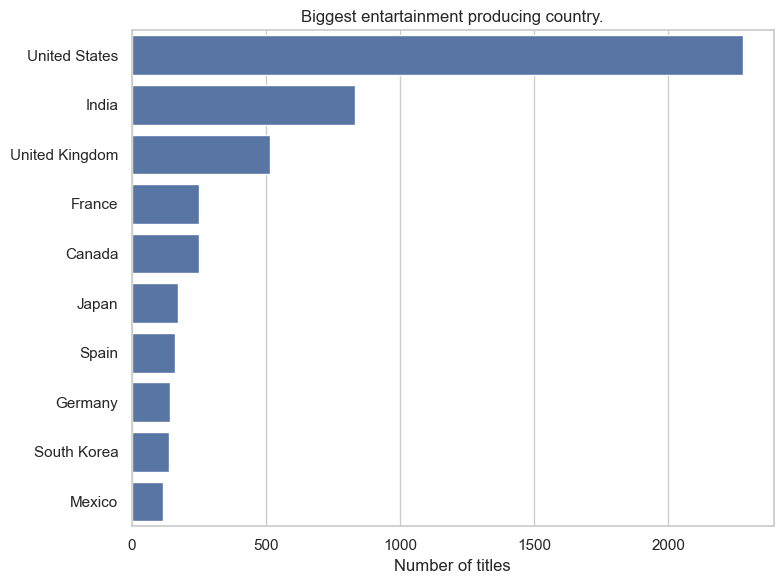

In [37]:
#the top 10 countries based on title count
df_known = df[df['country'] != "Unknown"] #filtered the country column with the values needed
countries = df_known.groupby('country').agg(
    title_count = ('title', 'count')
)
#grouped everything by country and counted all the titles for each


title_count = countries.sort_values(by='title_count', ascending=False).reset_index() #reseted the index for easier analysis in case of further change or if i want to grab something specific
print(title_count.head(10)) 
first_10 = title_count.head(10)

#as we can see down below, the USA leads with a number of 3642, more than 3X the second place India
fig, ax = plt.subplots(figsize = (8, 6))
sns.barplot(data=first_10, x = 'title_count', y = 'country', ax = ax)
plt.ylabel("")
plt.xlabel("Number of titles")
plt.title("Biggest entartainment producing country.")
plt.tight_layout()
plt.show()

## Which countries produce the most of each category?
We take the already filtered data frame from above and count by title. Again we can see that the USA has the highest movie production besides all almost 3X the second one - India. It stars in TV Shows too, taking up the first place. It is interesting that in South Korea based on the production from above, almost 3/4 out of the production, are TV Shows.

     type         country  Count
0   Movie   United States   1923
1   Movie           India    783
2   Movie  United Kingdom    378
4   Movie          Canada    211
5   Movie          France    201
7   Movie           Spain    133
8   Movie         Germany    126
11  Movie       Hong Kong     93
12  Movie          Mexico     84
13  Movie           China     84

       type         country  Count
3   TV Show   United States    357
6   TV Show  United Kingdom    136
9   TV Show           Japan     99
10  TV Show     South Korea     93
16  TV Show          Taiwan     64
21  TV Show           India     50
23  TV Show          France     49
28  TV Show          Canada     39
31  TV Show          Mexico     33
32  TV Show           China     32


/var/folders/81/vryb8mxs5flbzq30685135180000gn/T/ipykernel_7741/4161840935.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_movies, x='Count', y='country', ax=axes[0], palette='Blues_r')
/var/folders/81/vryb8mxs5flbzq30685135180000gn/T/ipykernel_7741/4161840935.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_tv_show, x='Count', y='country', ax=axes[1], palette='Reds_r')


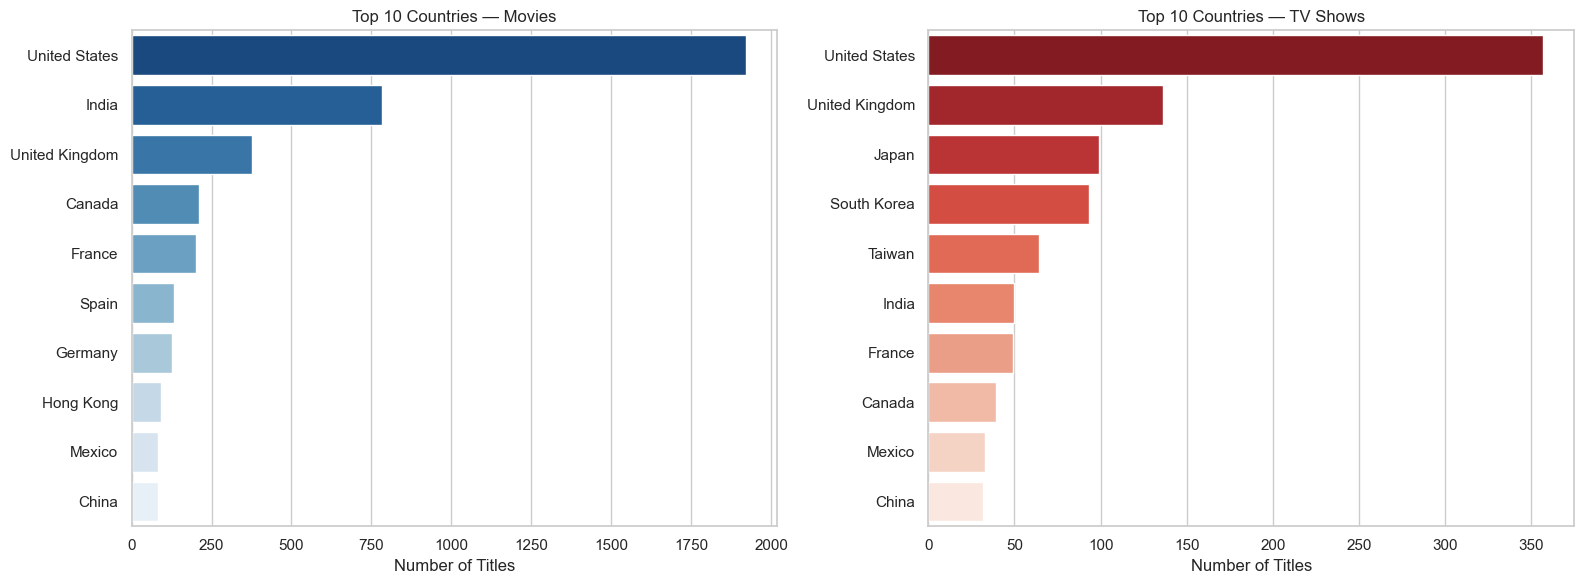

In [30]:
#the top 10 countries based on each type of streaming
title_max = df_known.groupby(['type', 'country']).agg(
    Count = ('title', 'count')
    
)
# used multi index grouping to group types and country and displayed how many titles of each category are there


high_count = title_max.sort_values(by='Count', ascending=False).reset_index() #sorted all my values so that i can grab what i need from the resulted data frame

#filtered the 10 highest values based on each category 
top_movies = high_count[high_count['type'] == 'Movie'].head(10)
top_tv_show = high_count[high_count['type'] == 'TV Show'].head(10)
print(top_movies)
print()
print(top_tv_show)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Movies chart
sns.barplot(data=top_movies, x='Count', y='country', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Countries — Movies')
axes[0].set_xlabel('Number of Titles')
axes[0].set_ylabel('')

# TV Shows chart
sns.barplot(data=top_tv_show, x='Count', y='country', ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 10 Countries — TV Shows')
axes[1].set_xlabel('Number of Titles')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## How much did Netflix's volume change over the years? 
First we extract the year from the whole date and count every title by year. We can see that Netflix wasn't really much untill 2016 when it marked an astonishing 472% increase difference from 2015 and added 5X more content that people could view. 

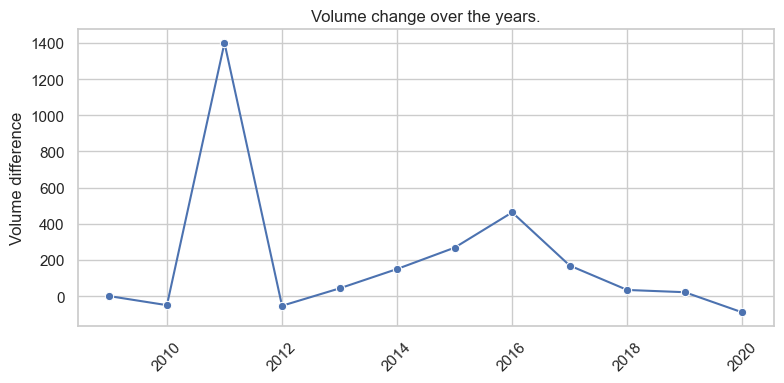

In [27]:
#How much did netflix's volume change over the years?
df_yearly = df_known.copy()
df_yearly['year_added'] = pd.to_datetime(df_yearly['date_added']).dt.year #changed the output to only take the years out of the whole data frame
yearly_titles = df_yearly.groupby('year_added').agg(
    added_movies = ('title', 'count')
)
#gathered all of the info i needed to complete my output, counted how many movies was netflix adding each year

yearly_titles['volume_difference'] = yearly_titles['added_movies'].pct_change() * 100 #this opperation is to see the actual increase in percentage 
yearly_titles

fix, ax = plt.subplots(figsize = (8, 4))
sns.lineplot(data = yearly_titles, x = "year_added", y = "volume_difference", ax=ax, marker='o')
plt.xlabel("")
plt.xticks(rotation = 45)
plt.ylabel("Volume difference")
plt.title("Volume change over the years.")
plt.tight_layout()
plt.show()